# CatBoost Model with In Depth Feature Engineering

**Metric:** Balanced accuracy (the competition's official evaluation metric, was previously using balanced F1, now using this)  
**Model:** CatBoost  
**Goal:** Introduce six new features using interaction, transformation, and grouping approaches, tune CatBoost with Optuna, and evaluate which features actually contributed using SHAP.

## Why CatBoost?

All previous notebooks used XGBoost and LightGBM, the instructions say to try something different and I haven't yet tried CatBoost. CatBoost handles categorical strings internally. It also builds symmetric trees, where every node at a given depth applies the same split rule. Since I am doing an ensemble later (see other notebook)... this type of model seemed better to work with given doing ensembling later (that was my theory anyways starting out).

In [14]:
#importing libraries
#also making process easier for graphs or whatever I need later by setting up some inital lists (also done in other notebooks)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from catboost import CatBoostClassifier, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED   = 42
TARGET = 'Irrigation_Need'
ORDER  = ['Low', 'Medium', 'High']

CAT_COLS = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
    'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'
]

## 1. Load Data

In [15]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')

Train shape: (630000, 21)
Test shape:  (270000, 20)


## 2. Feature Engineering

The three features from previous notebooks (stage_mulch, stress_index, water_deficit) are kept because they showed strong importance in both XGBoost and LightGBM. As previously stated, those features came from just the inital EDA step. Six new features are added:

In [16]:
# The soil moisture group mean is computed from training rows only.
# Computing from train only and then applying to both to stop data leakage
soil_moisture_by_type = train.groupby('Soil_Type')['Soil_Moisture'].mean()

print('Mean Soil_Moisture by Soil_Type (from training data):')
print(soil_moisture_by_type.sort_values().to_string())

Mean Soil_Moisture by Soil_Type (from training data):
Soil_Type
Sandy    36.924150
Silt     37.351386
Clay     37.393083
Loamy    37.574972


In [17]:
for df in [train, test]:

    #INFO FOR ALL THE FOLLOWING: adding 1 to the denominator prevents division by zero! 

    # previous features (already shown before but shown again here)

    # INTERACTION: Growth stage drives water demand
    # mulching controls how much moisture the soil retains. 
    df['stage_mulch'] = (
        df['Crop_Growth_Stage'].astype(str) + '_' + df['Mulching_Used'].astype(str)
    )

    # TRANSFORMATION: Temperature and wind increase water demand while soil
    # moisture reduces it. Dividing demand by supply gives stress score.
    df['stress_index'] = (
        (df['Temperature_C'] + df['Wind_Speed_kmh']) / (df['Soil_Moisture'] + 1)
    )

    # TRANSFORMATION: Temperature gives evaporation and rainfall is how much water supplied already
    # ratio gives a rough demand to supply balance score 
    df['water_deficit'] = df['Temperature_C'] / (df['Rainfall_mm'] / 100 + 1)

    # new features 

    # New Feature 1: region_season
    # Approach: INTERACTION
    # Region and Season each give partial climate information, maybe together can explain seasonality?
    df['region_season'] = df['Region'].astype(str) + '_' + df['Season'].astype(str)

    # New Feature 2: crop_water_source
    # Approach: INTERACTION
    # The crop type sets how much water is demanded
    # the water source sets how reliably demand can be met
    # water needing crop with a limited water source might be good indicator of needing more irrigation
    df['crop_water_source'] = df['Crop_Type'].astype(str) + '_' + df['Water_Source'].astype(str)

    # New Feature 3: sunlight_heat_load
    # Approach: TRANSFORMATION (multiplicative)
    # multiplying sunlight and temperature together might give estimate for evaporation or the heat demand on the crops
    # Different from stress_index because it focuses only on atmospheric conditions (not soil moisture) 
    #tried to look up to see if multiplying was good idea, saw some other people used it in the kaggle, decided to just try and see if it would work
    df['sunlight_heat_load'] = df['Sunlight_Hours'] * df['Temperature_C']

    # New Feature 4: rainfall_per_sunlight
    # Approach: TRANSFORMATION (ratio)
    # Sunlight drives evaporation (demand) while rainfall replaces lost moisture
    # Dividing rainfall by sunlight creates a supply/demand ratio
    #same logic as water_deficit kinda, just seeing if it being sunlight not temp makes a difference 
    df['rainfall_per_sunlight'] = df['Rainfall_mm'] / (df['Sunlight_Hours'] + 1)

    # New Feature 5: soil_type_mean_moisture
    # Approach: GROUPING
    # Different soil types retain water at very different rates
    # Mapping each row to the average Soil_Moisture for its soil type group gives the model a reference for normal moisture 
    df['soil_type_mean_moisture'] = df['Soil_Type'].map(soil_moisture_by_type)

    # New Feature 6: moisture_gap
    # Approach: GROUPING + TRANSFORMATION
    # With the group reference, we now compute how far each row deviates
    # Negative = drier than normal 
    # Positive = wetter.
    df['moisture_gap'] = df['Soil_Moisture'] - df['soil_type_mean_moisture']

print('Feature engineering complete.')
print('New features: region_season, crop_water_source, sunlight_heat_load,')
print('              rainfall_per_sunlight, soil_type_mean_moisture, moisture_gap')

Feature engineering complete.
New features: region_season, crop_water_source, sunlight_heat_load,
              rainfall_per_sunlight, soil_type_mean_moisture, moisture_gap


## 3. Prepare Features and Target

CatBoost accepts the string categoricals directly. In this section I am telling Catboost the column names so it handles them.

In [18]:
# The three string interaction features join the original categoricals 
#numeric features just left as is (float)
CAT_FEATURE_NAMES = CAT_COLS + ['stage_mulch', 'region_season', 'crop_water_source']

# CatBoost requires all categorical columns to be strings (so converting)
for df in [train, test]:
    for col in CAT_FEATURE_NAMES:
        df[col] = df[col].astype(str)

le = LabelEncoder()
y  = le.fit_transform(train[TARGET])

FEAT_COLS = [c for c in train.columns if c not in ['id', TARGET]]
X         = train[FEAT_COLS].copy()
X_test    = test[FEAT_COLS].copy()

print(f'Total features:                  {len(FEAT_COLS)}')
print(f'Categorical features (CatBoost): {len(CAT_FEATURE_NAMES)}')
print(f'Training rows:                   {len(X):,}')

Total features:                  28
Categorical features (CatBoost): 11
Training rows:                   630,000


## 4. CV Setup

Using 3 fold stratified CV on a 20K sample 

In [19]:
CV         = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
sample_idx = np.random.RandomState(SEED).choice(len(X), 20000, replace=False)
X_s        = X.iloc[sample_idx].reset_index(drop=True)
y_s        = y[sample_idx]

X_tr, X_val, y_tr, y_val = train_test_split(
    X_s, y_s, test_size=0.2, stratify=y_s, random_state=SEED
)

print(f'CV sample: {len(X_s):,} rows | Holdout: {len(X_val):,} rows')

CV sample: 20,000 rows | Holdout: 4,000 rows


In [20]:
#the competition scores on balanced accuracy
#setting up a function to make it easier to score 

def cv_balanced_accuracy_catboost(params, X, y, cv, cat_features):
    """
    Manual fold loop for CatBoost scored with balanced accuracy

    Balanced accuracy: the average recall across all three classes, gives each class equal weight.
    Using a Pool object so we can pass the categorical feature list and sample weights to CatBoost
    """
    fold_scores = []
    for tr_idx, val_idx in cv.split(X, y):
        X_tr_fold  = X.iloc[tr_idx].reset_index(drop=True)
        X_val_fold = X.iloc[val_idx].reset_index(drop=True)
        y_tr_fold  = y[tr_idx]
        y_val_fold = y[val_idx]

        sw = compute_sample_weight('balanced', y_tr_fold)

        train_pool = Pool(X_tr_fold,  label=y_tr_fold,
                          cat_features=cat_features, weight=sw)
        val_pool   = Pool(X_val_fold, cat_features=cat_features)

        model = CatBoostClassifier(**params, random_seed=SEED, verbose=0)
        model.fit(train_pool)

        preds = model.predict(val_pool).flatten().astype(int)
        fold_scores.append(balanced_accuracy_score(y_val_fold, preds))

    return np.array(fold_scores)

## 5. Manual Hyperparameter Configs

Three configs are tested before Optuna, same pattern as XGBoost/LightGBM notebooks from last HW. CatBoost-specific parameter: `depth`. 

In [21]:
configs = {

    # Config A: Moderate depth, slow learning rate, many iterations.
    # seeing the model's baseline performance
    'Config A (Moderate Depth, Slow LR)': dict(
        iterations=800,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=3.0,
        border_count=128,
        loss_function='MultiClass',
    ),

    # Config B: Shallower trees, higher learning rate.
    # much simpler than Config A, does simplicity handle class imbalance better? 
    'Config B (Shallow Trees, High LR)': dict(
        iterations=500,
        depth=4,
        learning_rate=0.15,
        l2_leaf_reg=5.0,
        border_count=64,
        loss_function='MultiClass',
    ),

    # Config C: Deeper trees, stronger regularization.
    # Depth 8 gives 256 leaves
    # more complex interactions between the new combination features 
    'Config C (Deeper Trees, Strong L2)': dict(
        iterations=600,
        depth=8,
        learning_rate=0.08,
        l2_leaf_reg=10.0,
        border_count=128,
        loss_function='MultiClass',
    ),
}

config_results = {}

for name, params in configs.items():
    scores = cv_balanced_accuracy_catboost(params, X_s, y_s, CV, CAT_FEATURE_NAMES)
    config_results[name] = (scores.mean(), scores.std())
    print(f'{name}: {scores.mean():.4f} +/- {scores.std():.4f}')

Config A (Moderate Depth, Slow LR): 0.9587 +/- 0.0037
Config B (Shallow Trees, High LR): 0.9558 +/- 0.0014
Config C (Deeper Trees, Strong L2): 0.9585 +/- 0.0042


## 6. Optuna Tuning

Optuna now searches the space more systematically using the ranges from manual info above.

In [22]:
def catboost_objective(trial):
    params = {
        'depth':         trial.suggest_int('depth', 4, 5),
        'iterations':    trial.suggest_int('iterations', 500, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.08, 0.15),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 5.0, 8.0),
        'border_count':  trial.suggest_categorical('border_count', [128, 130]),
        'loss_function': 'MultiClass',
    }
    scores = cv_balanced_accuracy_catboost(params, X_s, y_s, CV, CAT_FEATURE_NAMES)
    return scores.mean()

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(catboost_objective, n_trials=20)

print(f'Best Optuna params:        {study_cat.best_params}')
print(f'Best Balanced Accuracy CV: {study_cat.best_value:.4f}')

# Score Config D with the same fold loop so it compares directly to A, B, C
best_opt_params = {**study_cat.best_params, 'loss_function': 'MultiClass'}
scores_opt = cv_balanced_accuracy_catboost(best_opt_params, X_s, y_s, CV, CAT_FEATURE_NAMES)
config_results['Config D (Optuna)'] = (scores_opt.mean(), scores_opt.std())
print(f'Config D (Optuna): {scores_opt.mean():.4f} +/- {scores_opt.std():.4f}')

Best Optuna params:        {'depth': 4, 'iterations': 547, 'learning_rate': 0.13346250439385518, 'l2_leaf_reg': 5.731830239595378, 'border_count': 130}
Best Balanced Accuracy CV: 0.9607
Config D (Optuna): 0.9607 +/- 0.0033


## 7. Config Comparison Plot


=== CatBoost Config Summary ===
Config                                    Bal Acc      Std
------------------------------------------------------------
Config A (Moderate Depth, Slow LR)       0.9587   0.0037
Config B (Shallow Trees, High LR)        0.9558   0.0014
Config C (Deeper Trees, Strong L2)       0.9585   0.0042
Config D (Optuna)                        0.9607   0.0033


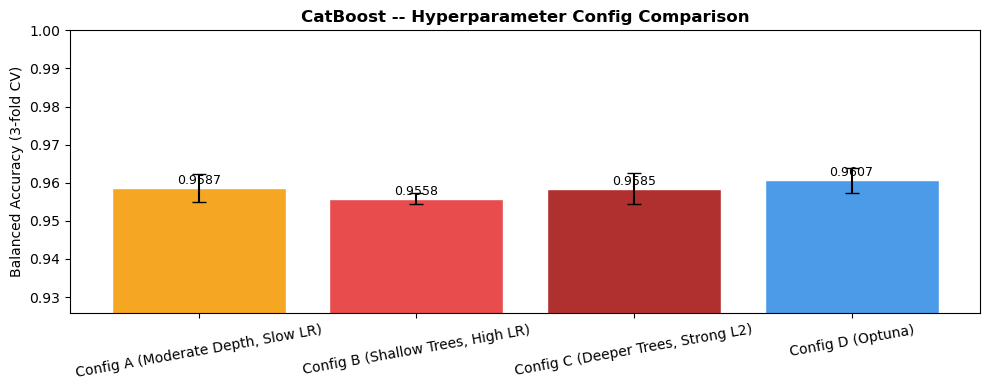

In [23]:
print('\n=== CatBoost Config Summary ===')
print(f'{"Config":<40} {"Bal Acc":>8}  {"Std":>7}')
print('-' * 60)
for name, (mean, std) in config_results.items():
    print(f'{name:<40} {mean:.4f}   {std:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
names  = list(config_results.keys())
means  = [config_results[n][0] for n in names]
stds   = [config_results[n][1] for n in names]
colors = ['#F5A623', '#E84C4C', '#B03030', '#4C9BE8']

bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=colors, edgecolor='white')
ax.set_ylim(min(means) - 0.03, 1.0)
ax.set_ylabel('Balanced Accuracy (3-fold CV)')
ax.set_title('CatBoost -- Hyperparameter Config Comparison', fontweight='bold')
ax.tick_params(axis='x', rotation=10)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Feature Importance: SHAP Values

Why SHAP? (and not just rank features like I did in XG Boost model from last HW)

In class we talked about how feature importance ranking can overstate features with many unique values among other issues like overstating binary values importance. SHAP values instead measure how much each feature actually shifted the model's prediction for each row. Averaging those absolute shifts across all rows and classes is more relable. 

The new features are highlighted separately in the plot so we can immediately see whether they contributed or were ignored.

In [24]:
# Train the best model on the holdout split for evaluation and SHAP
best_params_full = {
    **study_cat.best_params,
    'loss_function': 'MultiClass',
    'random_seed':   SEED,
    'verbose':       0,
}

sw_tr = compute_sample_weight('balanced', y_tr)
train_pool_eval = Pool(X_tr, label=y_tr,
                       cat_features=CAT_FEATURE_NAMES, weight=sw_tr)
val_pool_eval   = Pool(X_val, cat_features=CAT_FEATURE_NAMES)

best_cat = CatBoostClassifier(**best_params_full)
best_cat.fit(train_pool_eval)

y_pred = best_cat.predict(val_pool_eval).flatten().astype(int)

print(classification_report(y_val, y_pred, target_names=le.classes_))
print(f'Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred):.4f}')

              precision    recall  f1-score   support

        High       0.86      0.94      0.90       133
         Low       0.98      0.99      0.98      2352
      Medium       0.97      0.96      0.97      1515

    accuracy                           0.98      4000
   macro avg       0.94      0.96      0.95      4000
weighted avg       0.98      0.98      0.98      4000

Balanced Accuracy: 0.9626


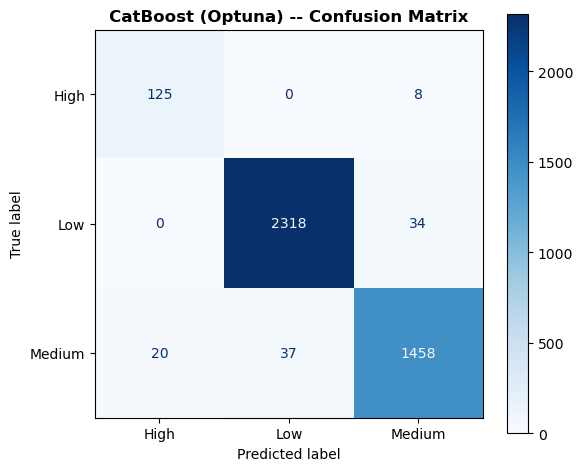

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_pred),
    display_labels=le.classes_
).plot(ax=ax, cmap='Blues')
ax.set_title('CatBoost (Optuna) -- Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# SHAP on 2000 validation rows. A subset keeps runtime manageable while
# still giving stable average importance estimates.
shap_sample = X_val.iloc[:2000].reset_index(drop=True)
shap_pool   = Pool(shap_sample, cat_features=CAT_FEATURE_NAMES)

# ShapValues returns shape (n_samples, n_features + 1, n_classes).
# The extra +1 column is the baseline bias value and is excluded below.
shap_vals_all = best_cat.get_feature_importance(shap_pool, type='ShapValues')

# Take the absolute value, then average across all samples and all classes.
# This gives one importance score per feature that summarizes how much it
# moved predictions on average, regardless of direction.
mean_abs_shap = np.abs(shap_vals_all[:, :, :-1]).mean(axis=(0, 1))
shap_series   = pd.Series(mean_abs_shap, index=FEAT_COLS).sort_values(ascending=False)

print('Top 15 features by mean absolute SHAP:')
print(shap_series.head(15).to_string())

Top 15 features by mean absolute SHAP:
stage_mulch               0.845957
Wind_Speed_kmh            0.712829
Soil_Moisture             0.677664
Temperature_C             0.572080
Crop_Growth_Stage         0.565960
moisture_gap              0.424890
stress_index              0.198607
Mulching_Used             0.151871
Rainfall_mm               0.092154
water_deficit             0.081429
Previous_Irrigation_mm    0.080667
rainfall_per_sunlight     0.079331
Soil_pH                   0.058696
Humidity                  0.055122
Sunlight_Hours            0.045246


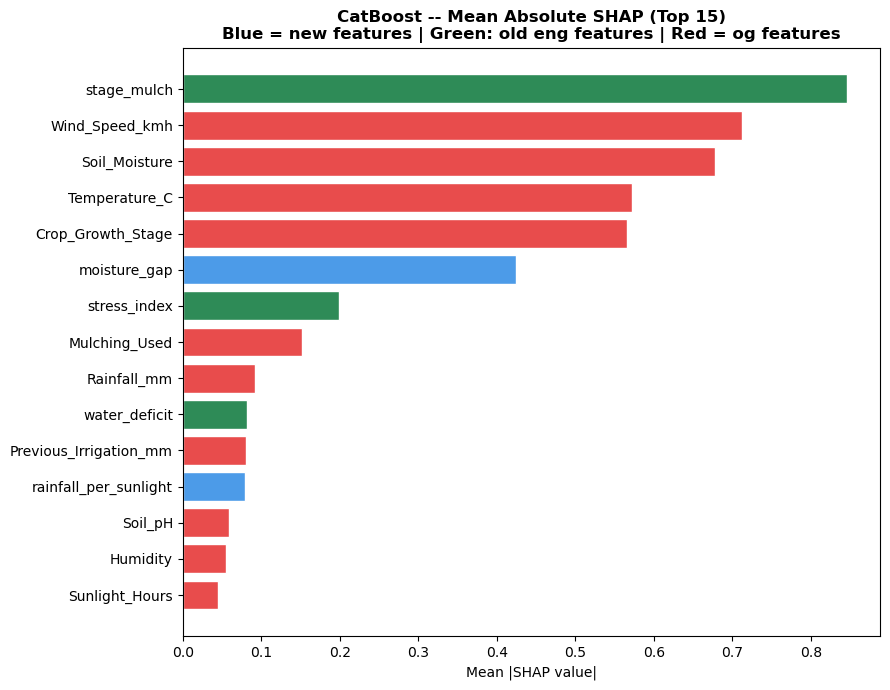

In [33]:
# Blue = new features added in this notebook
# Red = features carried over from previous notebooks
new_features = [
    'region_season', 'crop_water_source', 'sunlight_heat_load',
    'rainfall_per_sunlight', 'soil_type_mean_moisture', 'moisture_gap']

old_engineered = ['stage_mulch', 'stress_index', 'water_deficit']

top_shap = shap_series.head(15).sort_values()
colors   = ['#4C9BE8' if f in new_features else
             '#2E8B57' if f in old_engineered else
             "#E84C4C" for f in top_shap.index
             ]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_shap.index, top_shap.values, color=colors, edgecolor='white')
ax.set_title(
    'CatBoost -- Mean Absolute SHAP (Top 15)\n'
    'Blue = new features | Green: old eng features | Red = og features',
    fontweight='bold'
)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

#region_season, crop_water_source, sunlight_heat_load,' rainfall_per_sunlight, soil_type_mean_moisture, moisture_gap'

## 9. Kaggle Submission

In [34]:
sw_full   = compute_sample_weight('balanced', y)
full_pool = Pool(X, label=y, cat_features=CAT_FEATURE_NAMES, weight=sw_full)

final_cat = CatBoostClassifier(**best_params_full)
final_cat.fit(full_pool)

test_pool = Pool(X_test, cat_features=CAT_FEATURE_NAMES)
preds     = final_cat.predict(test_pool).flatten().astype(int)

submission = pd.DataFrame({
    'id':   test['id'],
    TARGET: le.inverse_transform(preds)
})
submission.to_csv('submission_catboost_optuna.csv', index=False)

print('Saved: submission_catboost_optuna.csv')
print(submission[TARGET].value_counts())

Saved: submission_catboost_optuna.csv
Irrigation_Need
Low       159620
Medium    100098
High       10282
Name: count, dtype: int64
